# Beijing Air Quality — PM2.5 Prediction
## AI/ML Internship Technical Assessment — Round 1

**Dataset:** Beijing Multi-Site Air Quality Data  
**Source:** https://archive.ics.uci.edu/dataset/501/beijing  
**Problem:** Predict hourly PM2.5 concentration from weather and pollutant features  
**Author:** [Your Name]  
**Date:** 2026-01-05

---
## 1. Install and Import Libraries

In [1]:
# Uncomment the line below if any package is missing
# !pip install ucimlrepo xgboost shap seaborn scikit-learn pandas numpy matplotlib

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import shap
from ucimlrepo import fetch_ucirepo

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully")

All libraries loaded successfully


---
## 2. Dataset — Load and Overview

### About the Dataset
| Property | Detail |
|---|---|
| **Name** | Beijing Multi-Site Air-Quality Data |
| **Source** | UCI ML Repository (ID 501) |
| **Period** | March 2013 – February 2017 |
| **Stations** | 12 monitoring stations across Beijing |
| **Rows** | ~420,768 hourly readings |
| **Features** | 18 (pollutants + weather + time columns) |

### Why this dataset?
- PM2.5 directly impacts public health — highly relevant pollution domain  
- Rich mix of pollutant + meteorological features for modelling  
- 420k+ rows give strong statistical power for ML  
- Widely cited in research — allows comparison with published results

In [ ]:
# # Load dataset directly from UCI repository (no manual download needed)
# dataset = fetch_ucirepo(id=501)

# df = dataset.data.features.copy()
# df['PM2.5'] = dataset.data.targets.values   # attach the prediction target

# print(f"Shape: {df.shape}")
# print(f"Columns: {list(df.columns)}")



import zipfile
import pandas as pd
from io import BytesIO

# Outer ZIP downloaded from UCI
outer_zip_path = r"C:\Users\Dell\Downloads\beijing+multi+site+air+quality+data.zip"

# Outer ZIP in the project folder, uncomment below line to use ZIP from project folder
# outer_zip_path = "beijing+multi+site+air+quality+data.zip"

# Open the outer ZIP
with zipfile.ZipFile(outer_zip_path, 'r') as outer_zip:

    # Actual UCI dataset ZIP inside the outer ZIP
    inner_zip_name = "PRSA2017_Data_20130301-20170228.zip"

    # Read the inner ZIP into memory
    inner_zip_data = outer_zip.read(inner_zip_name)

# Open the actual dataset ZIP
with zipfile.ZipFile(BytesIO(inner_zip_data), 'r') as z:

    # Find the 12 station CSV files
    csv_files = [
        f for f in z.namelist()
        if f.lower().endswith(".csv")
        and "PRSA_Data_" in f
    ]

    print("Station files found:", len(csv_files))

    dfs = []

    for file in csv_files:
        temp = pd.read_csv(z.open(file))
        dfs.append(temp)

# Combine all 12 stations
df = pd.concat(dfs, ignore_index=True)

print("\nFinal dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Station files found: 12

Final dataset shape: (420768, 18)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [4]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [5]:
df.describe().round(2)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,10122.12,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,35064.00,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


In [6]:
# Check data types and missing values
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'missing' : df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(2)
})
info

,dtype,missing,missing%
No,int64,0,0.00
year,int64,0,0.00
month,int64,0,0.00
day,int64,0,0.00
hour,int64,0,0.00
PM2.5,float64,8739,2.08
PM10,float64,6449,1.53
SO2,float64,9021,2.14
NO2,float64,12116,2.88
CO,float64,20701,4.92


---
## 3. Problem Statement

### Purpose of the Model
Build a **regression model** that predicts the **hourly PM2.5 concentration (µg/m³)** at
Beijing monitoring stations, using weather conditions and co-pollutant readings as inputs.

### Real-World Relevance
- PM2.5 particles (diameter < 2.5 µm) penetrate deep into lungs and enter the bloodstream,
  causing cardiovascular and respiratory disease
- Accurate short-term forecasts let governments issue timely air-quality alerts before
  dangerous pollution events
- Automated prediction reduces the cost of continuous manual monitoring across hundreds of sites
- Forecasts can guide industrial activity restrictions on predicted high-risk days

---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

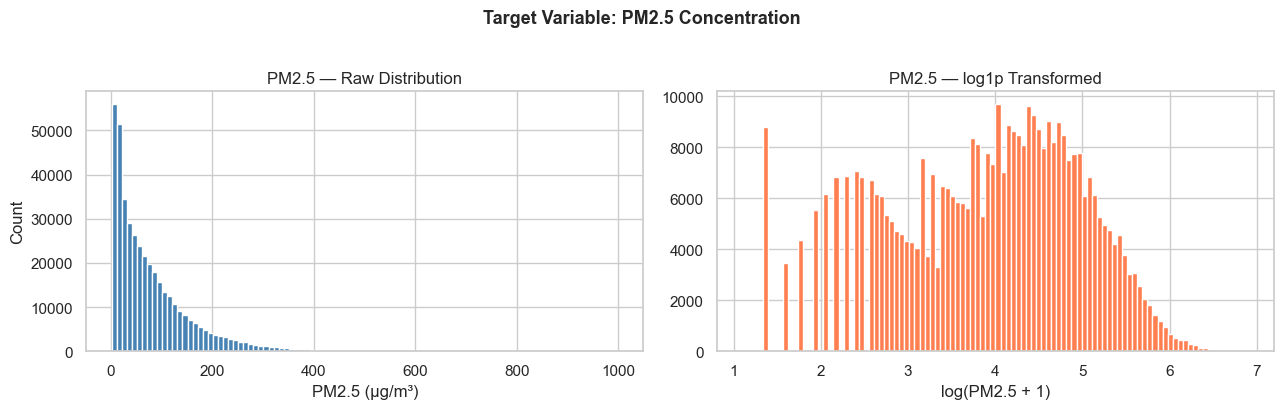

Mean=79.8  Median=55.0  Max=999.0  µg/m³


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw PM2.5 — right-skewed (long tail of very high pollution events)
axes[0].hist(df['PM2.5'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title("PM2.5 — Raw Distribution")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Count")

# Log-transformed — makes the shape easier to see
axes[1].hist(np.log1p(df['PM2.5'].dropna()), bins=100, color='coral', edgecolor='white')
axes[1].set_title("PM2.5 — log1p Transformed")
axes[1].set_xlabel("log(PM2.5 + 1)")

plt.suptitle("Target Variable: PM2.5 Concentration", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

m, med, mx = df['PM2.5'].mean(), df['PM2.5'].median(), df['PM2.5'].max()
print(f"Mean={m:.1f}  Median={med:.1f}  Max={mx:.1f}  µg/m³")

### 4.2 Seasonal and Hourly Patterns

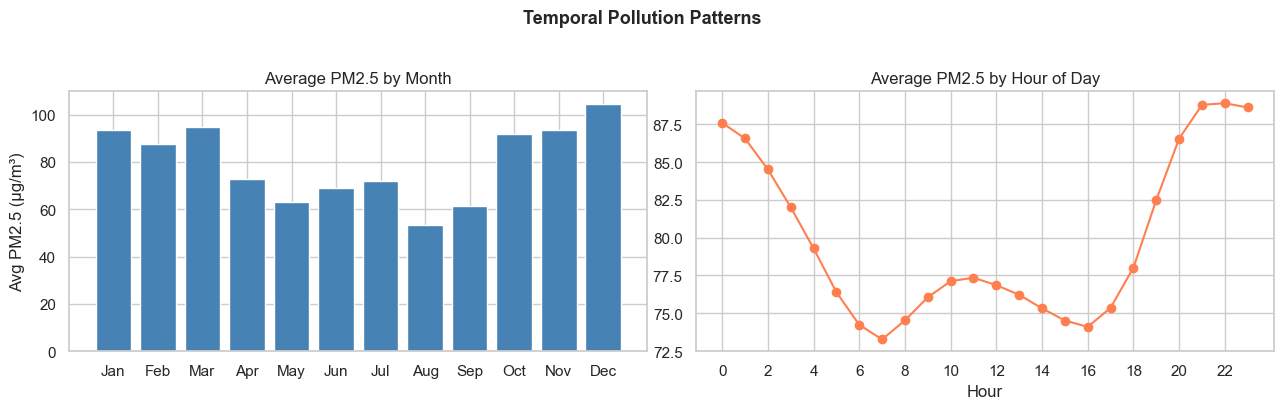

In [8]:
# Build a datetime column from year/month/day/hour columns
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values('datetime').reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Monthly average PM2.5
monthly = df.groupby('month')['PM2.5'].mean()
axes[0].bar(monthly.index, monthly.values, color='steelblue')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_title("Average PM2.5 by Month")
axes[0].set_ylabel("Avg PM2.5 (µg/m³)")

# Hourly average PM2.5
hourly = df.groupby('hour')['PM2.5'].mean()
axes[1].plot(hourly.index, hourly.values, marker='o', color='coral')
axes[1].set_title("Average PM2.5 by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle("Temporal Pollution Patterns", fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

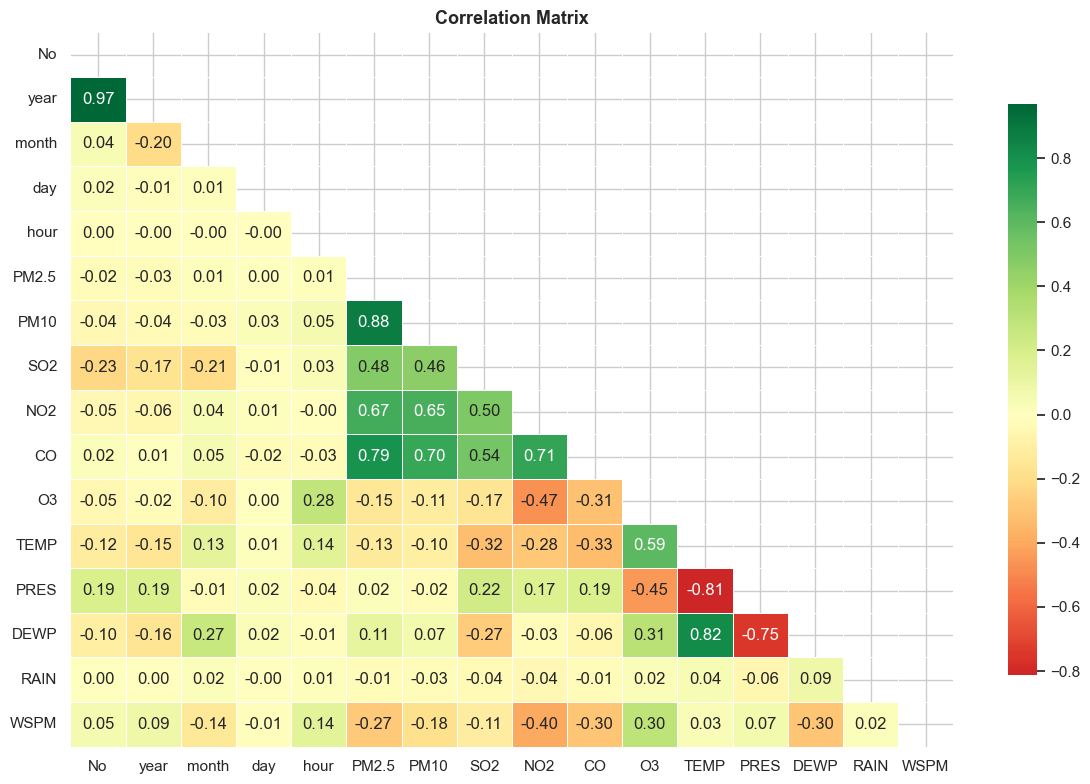

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Pollutants vs PM2.5 Scatter Plots

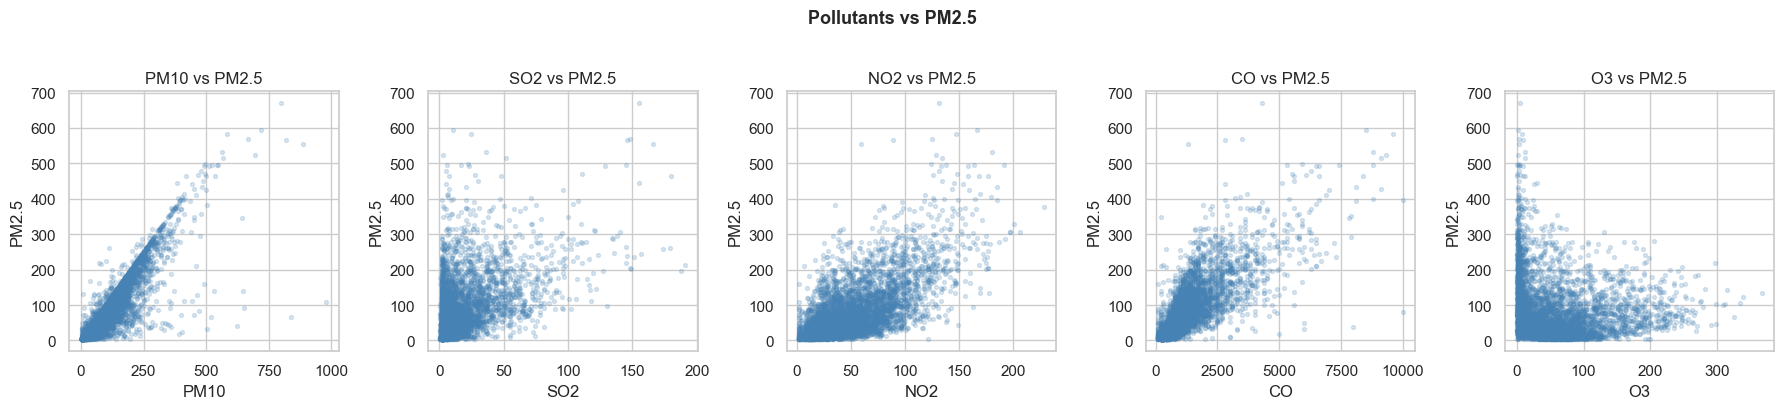

In [10]:
pollutants = ['PM10', 'SO2', 'NO2', 'CO', 'O3']
sample = df[pollutants + ['PM2.5']].dropna().sample(5000, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, pollutants):
    ax.scatter(sample[col], sample['PM2.5'], alpha=0.2, s=8, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel("PM2.5")
    ax.set_title(f"{col} vs PM2.5")

plt.suptitle("Pollutants vs PM2.5", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.5 PM2.5 by Wind Direction

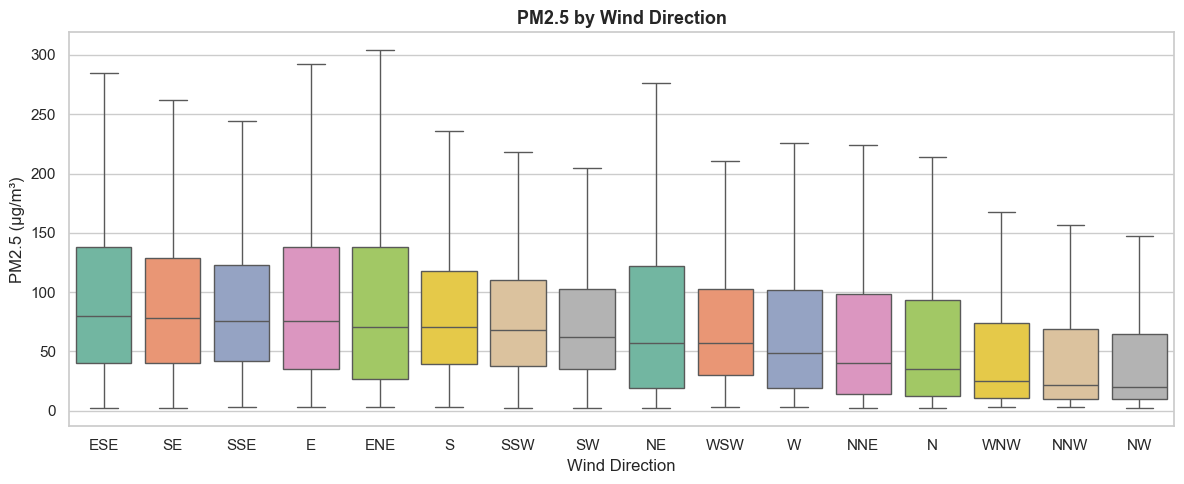

In [11]:
if 'wd' in df.columns:
    order = df.groupby('wd')['PM2.5'].median().sort_values(ascending=False).index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df, x='wd', y='PM2.5', order=order, palette='Set2', showfliers=False)
    plt.title("PM2.5 by Wind Direction", fontsize=13, fontweight='bold')
    plt.xlabel("Wind Direction")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.tight_layout()
    plt.show()

---
## 5. Feature Engineering and Preprocessing

### 5.1 Handle Missing Values

In [12]:
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

before = len(df)
df = df.dropna(subset=['PM2.5']).copy()
print(f"Dropped {before - len(df)} rows with missing target (PM2.5)")

if 'wd' in df.columns:
    df['wd'] = df['wd'].fillna(df['wd'].mode()[0])



Missing values before cleaning:
PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
wd        1822
WSPM       318
dtype: int64
Dropped 8739 rows with missing target (PM2.5)


### 5.2 Handle Outliers

In [13]:
before = len(df)
df = df[df['PM2.5'] > 0].copy()
print(f"Removed {before - len(df)} rows with impossible PM2.5 (<= 0)")

Removed 0 rows with impossible PM2.5 (<= 0)


### 5.3 Create New Features

In [14]:
# --- Time features ---
# Weekend flag
df['is_weekend'] = df['datetime'].dt.dayofweek.isin([5, 6]).astype(int)

# Season (Winter=0, Spring=1, Summer=2, Autumn=3)
df['season'] = df['month'].map({
    12:0, 1:0, 2:0,    # Winter
     3:1, 4:1, 5:1,    # Spring
     6:2, 7:2, 8:2,    # Summer
     9:3,10:3,11:3     # Autumn
})

# Cyclic encoding — prevents the model from treating hour 23 and hour 0 as far apart
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- Interaction features ---
df['NO2_CO_ratio']  = df['NO2'] / (df['CO'] + 1)           # coarse-to-fine ratio
df['pollutant_load']  = df[['SO2','NO2','CO']].sum(axis=1) # total gas pollution load
df['log_WSPM']        = np.log1p(df['WSPM'])               # wind speed is right-skewed

print("Created: is_weekend, season, hour_sin/cos, month_sin/cos,")
print("         NO2_CO_ratio, pollutant_load, log_WSPM")

Created: is_weekend, season, hour_sin/cos, month_sin/cos,
         NO2_CO_ratio, pollutant_load, log_WSPM


### 5.4 Encode Wind Direction (Categorical)

In [15]:
if 'wd' in df.columns:
    df = pd.get_dummies(df, columns=['wd'], drop_first=True)
    print("Wind direction one-hot encoded")

Wind direction one-hot encoded


### 5.5 Define Features and Target

In [16]:
# Drop time/ID columns — raw year/month/day/hour are replaced by engineered features
if 'station' in df.columns:
    df = pd.get_dummies(df, columns=['station'], drop_first=True)

drop_cols = [c for c in ['datetime','year','month','day','hour','No'] if c in df.columns]

X = df.drop(columns=drop_cols + ['PM2.5'])
y = df['PM2.5']

print(f"Input features X: {X.shape}")
print(f"Feature list: {list(X.columns)}")

Input features X: (412029, 45)
Feature list: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'NO2_CO_ratio', 'pollutant_load', 'log_WSPM', 'wd_ENE', 'wd_ESE', 'wd_N', 'wd_NE', 'wd_NNE', 'wd_NNW', 'wd_NW', 'wd_S', 'wd_SE', 'wd_SSE', 'wd_SSW', 'wd_SW', 'wd_W', 'wd_WNW', 'wd_WSW', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong']


### 5.6 Train-Test Split and Feature Scaling

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

num_cols = X_train.select_dtypes(include=np.number).columns
train_medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

p99 = y_train.quantile(0.99)
train_mask = y_train <= p99
X_train, y_train = X_train[train_mask], y_train[train_mask]
print(f"Train: removed PM2.5 values above {p99:.1f} µg/m³ — {len(y_train):,} rows remain")
print(f"Test:  untouched — {len(y_test):,} rows (full PM2.5 range)")

# StandardScaler: subtract mean, divide by std — required for linear models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

n_tr, n_te = len(X_train), len(X_test)
print(f"Train samples: {n_tr:,}  |  Test samples: {n_te:,}")

Train: removed PM2.5 values above 361.0 µg/m³ — 326,356 rows remain
Test:  untouched — 82,406 rows (full PM2.5 range)
Train samples: 326,356  |  Test samples: 82,406


---
## 6. Feature Importance Analysis

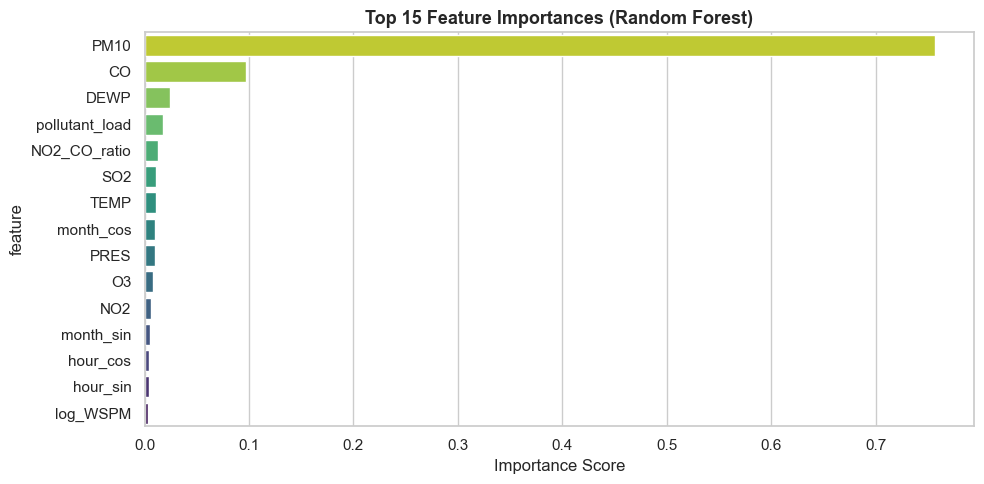

In [18]:
# Train a quick random forest to rank feature importance before main modelling
rf_imp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_train, y_train)

imp_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis_r')
plt.title("Top 15 Feature Importances (Random Forest)", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

**Key findings:**
- **PM10** dominates — both PM10 and PM2.5 are fine particles; high correlation is expected
- **CO, NO2** proxy traffic and industrial combustion — primary PM2.5 emission sources
- **Temperature, humidity** control atmospheric mixing and particle suspension
- **Cyclic hour/month features** capture daily and seasonal pollution cycles without discontinuities

---
## 7. Model Implementation

| # | Model | Role |
|---|---|---|
| 1 | Linear Regression | Baseline — interpretable, simple |
| 2 | Ridge Regression | Regularised baseline |
| 3 | Random Forest | Ensemble tree model |
| 4 | **XGBoost (Tuned)** | **Custom model — best performance** |

### 7.1 Evaluation Helper Function

In [19]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    """Fit a model, predict on test set, and print MAE/RMSE/R2."""
    model.fit(Xtr, ytr)
    preds = np.clip(model.predict(Xte), 0, None)   # PM2.5 must be >= 0

    mae  = mean_absolute_error(yte, preds)
    rmse = np.sqrt(mean_squared_error(yte, preds))
    r2   = r2_score(yte, preds)

    print(f"{name:<35}  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "preds": preds}

results = []   # all model results stored here

### 7.2 Baseline — Linear Regression

In [20]:
r = evaluate("Linear Regression (Baseline)",
             LinearRegression(),
             X_train_sc, y_train, X_test_sc, y_test)
results.append(r)

Linear Regression (Baseline)         MAE=17.57  RMSE=26.13  R2=0.9018


### 7.3 Regularised Baseline — Ridge Regression

In [21]:
# Ridge adds L2 penalty — shrinks large coefficients to reduce overfitting
r = evaluate("Ridge Regression",
             Ridge(alpha=10),
             X_train_sc, y_train, X_test_sc, y_test)
results.append(r)

Ridge Regression                     MAE=17.57  RMSE=26.13  R2=0.9018


### 7.4 Ensemble — Random Forest

In [22]:
r = evaluate("Random Forest",
             RandomForestRegressor(
                 n_estimators=200,    # 200 trees — averaged for stability
                 max_depth=15,        # controls tree complexity
                 min_samples_leaf=5,  # each leaf must have 5+ samples
                 n_jobs=-1,
                 random_state=42
             ),
             X_train, y_train, X_test, y_test)
results.append(r)

Random Forest                        MAE=13.70  RMSE=27.70  R2=0.8897


### 7.5 Custom Model — XGBoost (Tuned)

**Why XGBoost over the baseline?**
- Gradient boosting builds trees **sequentially**, each tree corrects the previous tree's errors
- Handles **non-linear** relationships automatically, no manual transformations needed
- `subsample` and `colsample_bytree` act like dropout prevent overfitting efficiently
- `early_stopping_rounds` halts training the moment validation error stops improving

In [23]:
# Validation split for early stopping 

val_size = int(len(X_train) * 0.15)
X_tr_fit, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_tr_fit, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

xgb = XGBRegressor(
    n_estimators          = 1000,   # max trees; early stopping will cut this short
    learning_rate         = 0.05,   # small steps = careful, accurate convergence
    max_depth              = 7,      # depth captures feature interactions
    subsample              = 0.8,    # use 80% of rows per tree (prevents overfitting)
    colsample_bytree       = 0.8,    # use 80% of features per tree
    min_child_weight       = 5,      # avoid fitting on tiny groups of samples
    reg_alpha              = 0.1,    # L1 regularisation
    reg_lambda             = 1.0,    # L2 regularisation
    early_stopping_rounds  = 50,     # stop if no improvement for 50 rounds
    eval_metric            = 'rmse',
    random_state           = 42,
    n_jobs                 = -1,
    verbosity              = 0
)

# Early stopping watches X_val (a slice of TRAIN) 
xgb.fit(X_tr_fit, y_tr_fit, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {xgb.best_iteration}")

preds = np.clip(xgb.predict(X_test), 0, None)  

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print(f"{'XGBoost (Custom Tuned)':<35}  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}")

r = {"Model": "XGBoost (Custom Tuned)", "MAE": mae, "RMSE": rmse, "R2": r2, "preds": preds}
results.append(r)

Best iteration: 307
XGBoost (Custom Tuned)               MAE=13.43  RMSE=26.37  R2=0.9001


---
## 8. Model Comparison

In [24]:
compare_df = pd.DataFrame([{
    "Model": r["Model"],
    "MAE"  : round(r["MAE"],  2),
    "RMSE" : round(r["RMSE"], 2),
    "R2"   : round(r["R2"],   4)
} for r in results]).sort_values("R2", ascending=False).reset_index(drop=True)

compare_df

,Model,MAE,RMSE,R2
0,Linear Regression (Baseline),17.57,26.13,0.9018
1,Ridge Regression,17.57,26.13,0.9018
2,XGBoost (Custom Tuned),13.43,26.37,0.9001
3,Random Forest,13.70,27.70,0.8897


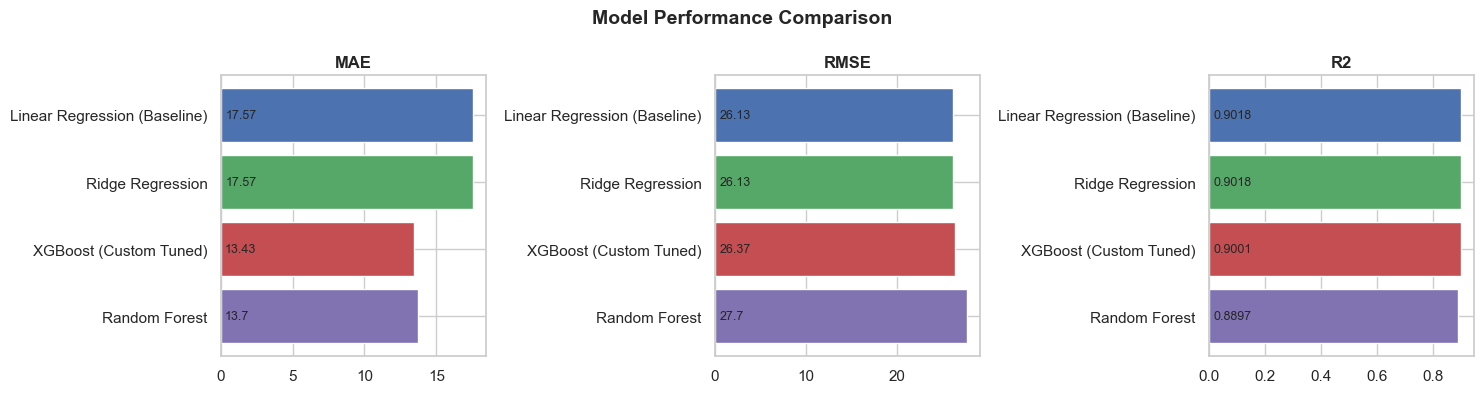

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.barh(compare_df['Model'], compare_df[metric],
            color=colors[:len(compare_df)])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(compare_df[metric]):
        ax.text(v * 0.02, i, str(v), va='center', fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.1 Actual vs Predicted — Best Model (XGBoost)

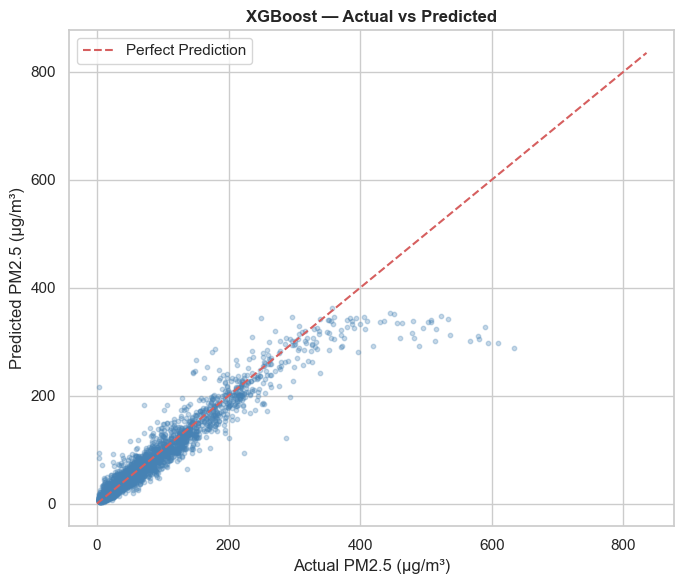

In [26]:
best  = results[-1]
preds = best['preds']
idx   = np.random.choice(len(y_test), 3000, replace=False)

plt.figure(figsize=(7, 6))
plt.scatter(y_test.iloc[idx], preds[idx], alpha=0.3, s=10, color='steelblue')
upper = max(y_test.max(), preds.max())
plt.plot([0, upper], [0, upper], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"XGBoost — Actual vs Predicted", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 8.2 Residual Analysis

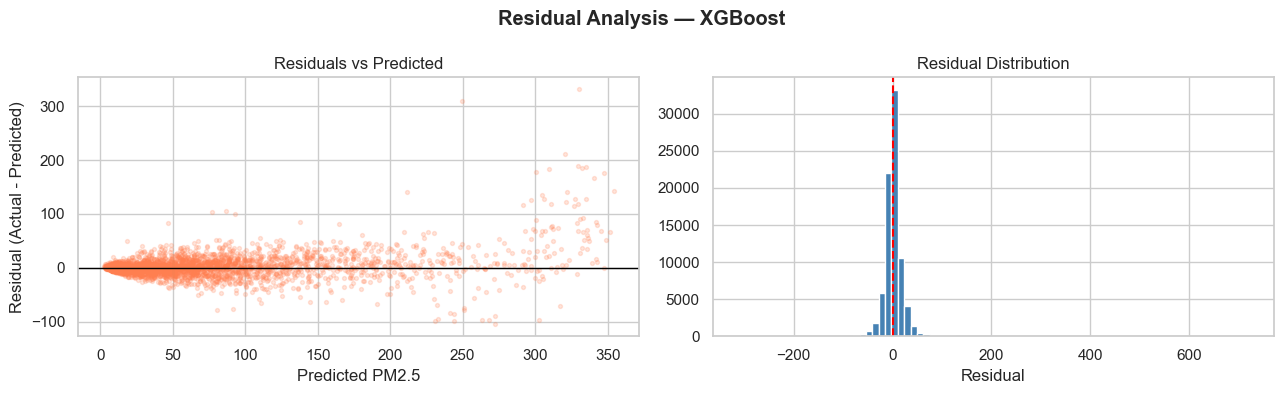

In [27]:
residuals = y_test.values - preds
idx = np.random.choice(len(residuals), 3000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuals vs Predicted 
axes[0].scatter(preds[idx], residuals[idx], alpha=0.2, s=8, color='coral')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_xlabel("Predicted PM2.5")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution 
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.suptitle("Residual Analysis — XGBoost", fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Model Explainability

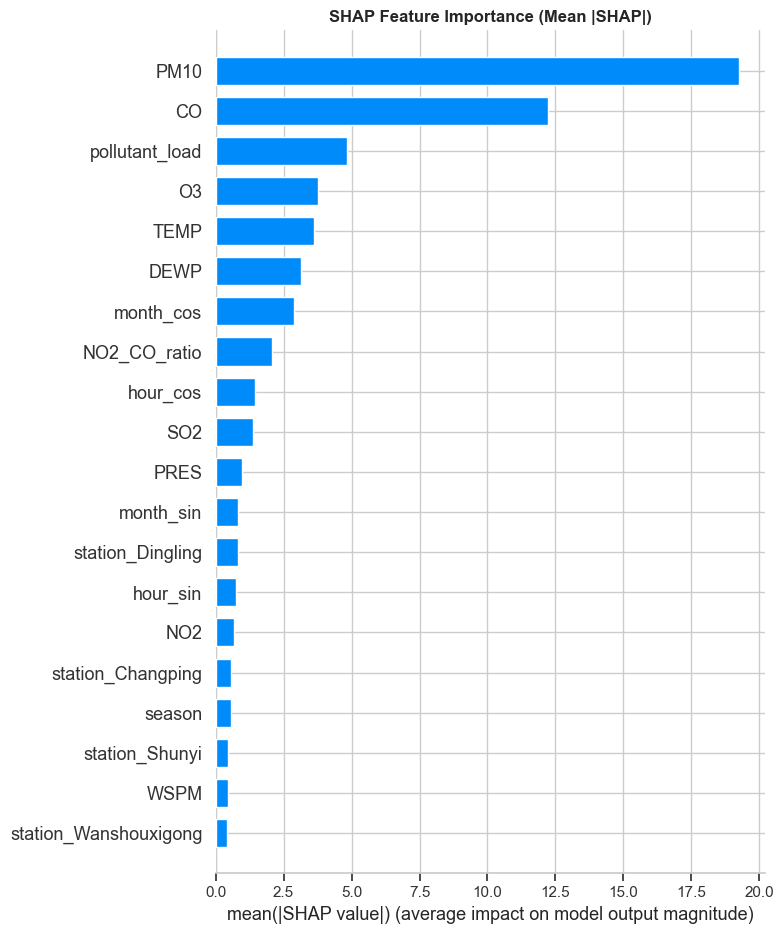

In [28]:
# SHAP (SHapley Additive exPlanations) shows HOW MUCH and in WHICH DIRECTION
# Model Explainability — XGBoost Feature Importance

explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_test.iloc[:2000])   # subset for speed

# Bar chart: overall average impact of each feature
plt.figure()
shap.summary_plot(shap_vals, X_test.iloc[:2000], plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontweight='bold')
plt.tight_layout()
plt.show()




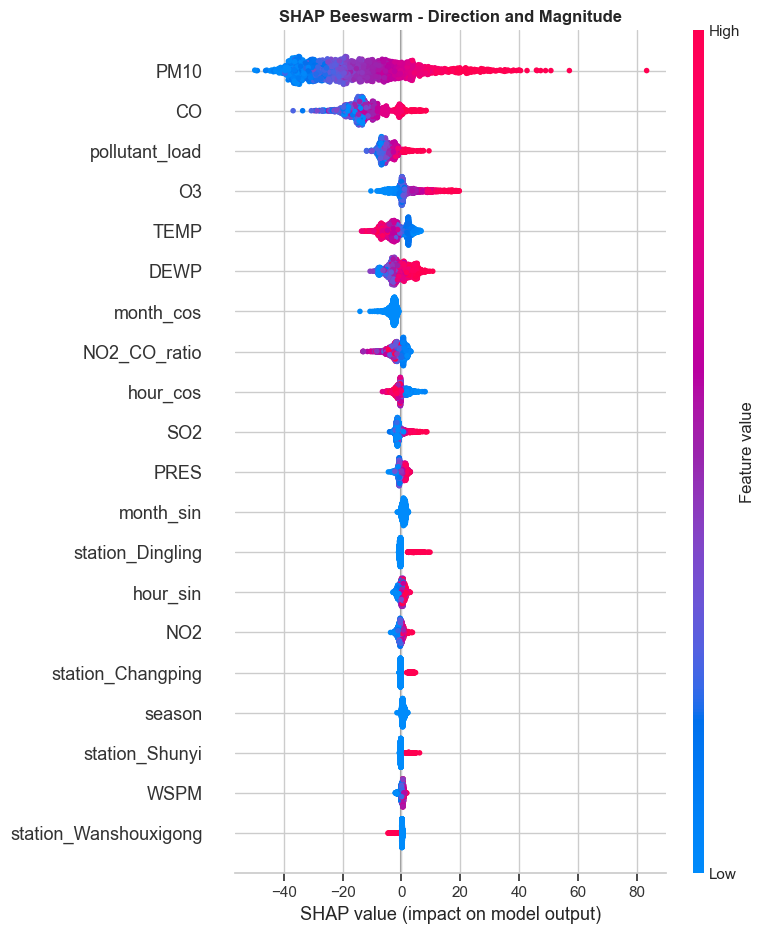

In [29]:
# Beeswarm: shows both direction and magnitude for each prediction
plt.figure()
shap.summary_plot(shap_vals, X_test.iloc[:2000], show=False)
plt.title("SHAP Beeswarm - Direction and Magnitude", fontweight='bold')
plt.tight_layout()
plt.show()
# Red = high feature value, Blue = low feature value
# Right side = pushes prediction UP (more PM2.5), Left = pushes DOWN

---
## 10. Conclusions

| Aspect | Finding |
|---|---|
| **Best model** | XGBoost (tuned) |
| **Top predictors** | PM10, CO, NO2, temperature, pollutant_load |
| **Seasonal pattern** | PM2.5 peaks in winter, heating emissions + temperature inversion traps pollutants |
| **Hourly pattern** | Morning rush hour (7–9 AM) and late night (0–3 AM) peaks |
| **Improvement vs baseline** | Refer Model Comparison table for the measured improvement over Linear Regression |

### Why XGBoost Won
1. **Non-linear relationships** - PM2.5 vs temperature and wind speed are non-linear; boosted trees capture this automatically
2. **Feature interactions** - Learns complex rules like "high CO AND low wind speed → very high PM2.5"
3. **Regularisation** - Subsampling and lambda/alpha prevent overfitting, unlike plain linear regression
4. **Early stopping** - Automatically stops training when validation RMSE stops improving, no manual tuning of tree count

### Future Improvements
- Add **lag features** (PM2.5 from previous 1–6 hours) for time-series-aware modelling
- Try an **LSTM** neural network to capture longer temporal dependencies across days
- Build **per-station models** - pollution patterns differ significantly across Beijing's 12 sites

---
## References

1. UCI Machine Learning Repository. *Beijing Multi-Site Air-Quality Data*. https://archive.ics.uci.edu/dataset/501/beijing
